In [1]:
!pip install pandas


In [38]:
import pandas as pd

file_path = r"C:\Users\PC\Downloads\abalone\abalone.data"

columns = [
    'Sex', 'Length', 'Diameter', 'Height',
    'WholeWeight', 'ShuckedWeight', 'VisceraWeight',
    'ShellWeight', 'Rings'
]

abalone_data = pd.read_csv(file_path, header=None, names=columns)

print(abalone_data.head())


  Sex  Length  Diameter  Height  WholeWeight  ShuckedWeight  VisceraWeight  \
0   M   0.455     0.365   0.095       0.5140         0.2245         0.1010   
1   M   0.350     0.265   0.090       0.2255         0.0995         0.0485   
2   F   0.530     0.420   0.135       0.6770         0.2565         0.1415   
3   M   0.440     0.365   0.125       0.5160         0.2155         0.1140   
4   I   0.330     0.255   0.080       0.2050         0.0895         0.0395   

   ShellWeight  Rings  
0        0.150     15  
1        0.070      7  
2        0.210      9  
3        0.155     10  
4        0.055      7  


In [40]:

file_path = r"C:\Users\PC\Downloads\abalone\abalone.names"

with open(file_path, 'r') as file:
    content = file.read()

print(content)


1. Title of Database: Abalone data

2. Sources:

   (a) Original owners of database:
	Marine Resources Division
	Marine Research Laboratories - Taroona
	Department of Primary Industry and Fisheries, Tasmania
	GPO Box 619F, Hobart, Tasmania 7001, Australia
	(contact: Warwick Nash +61 02 277277, wnash@dpi.tas.gov.au)

   (b) Donor of database:
	Sam Waugh (Sam.Waugh@cs.utas.edu.au)
	Department of Computer Science, University of Tasmania
	GPO Box 252C, Hobart, Tasmania 7001, Australia

   (c) Date received: December 1995


3. Past Usage:

   Sam Waugh (1995) "Extending and benchmarking Cascade-Correlation", PhD
   thesis, Computer Science Department, University of Tasmania.

   -- Test set performance (final 1044 examples, first 3133 used for training):
	24.86% Cascade-Correlation (no hidden nodes)
	26.25% Cascade-Correlation (5 hidden nodes)
	21.5%  C4.5
	 0.0%  Linear Discriminate Analysis
	 3.57% k=5 Nearest Neighbour
      (Problem encoded as a classification task)

   -- Data set samp

In [42]:

file_path = r"C:\Users\PC\Downloads\abalone\Index"

with open(file_path, 'r') as file:
    content = file.read()

print(content)


Index of abalone

02 Dec 1996      114 Index
12 Jun 1996   191873 abalone.data
12 Jun 1996     4319 abalone.names



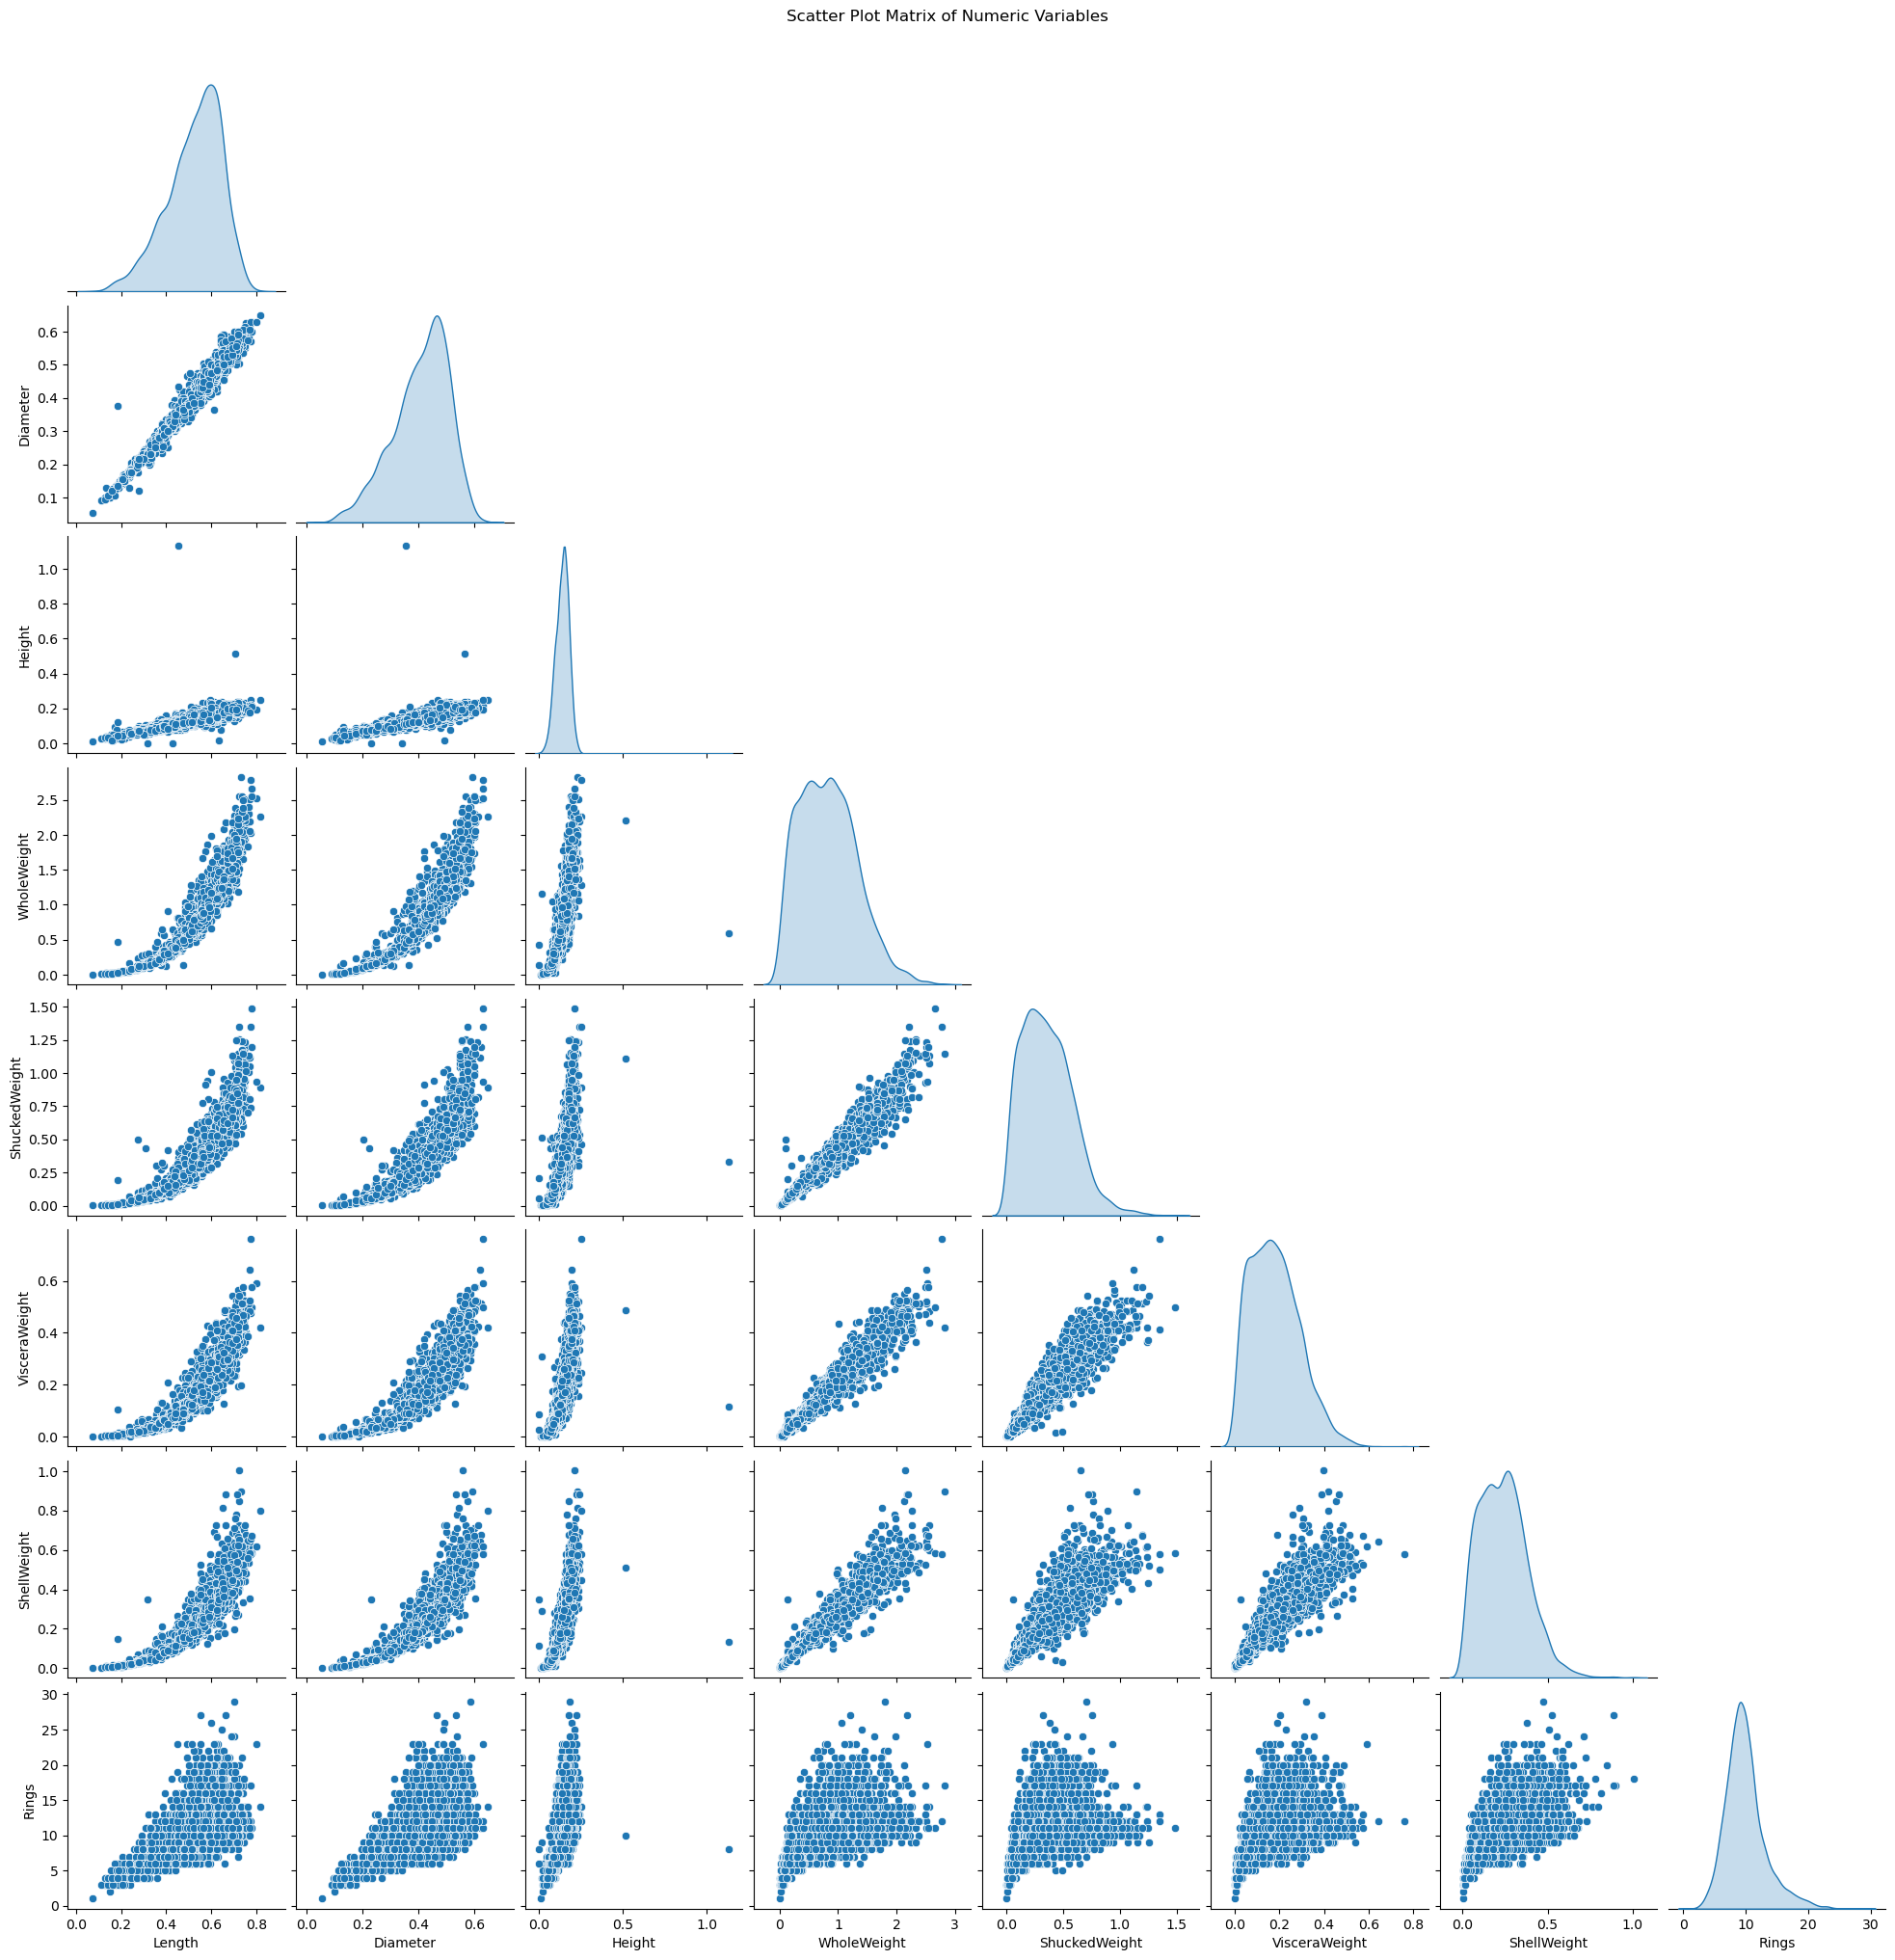

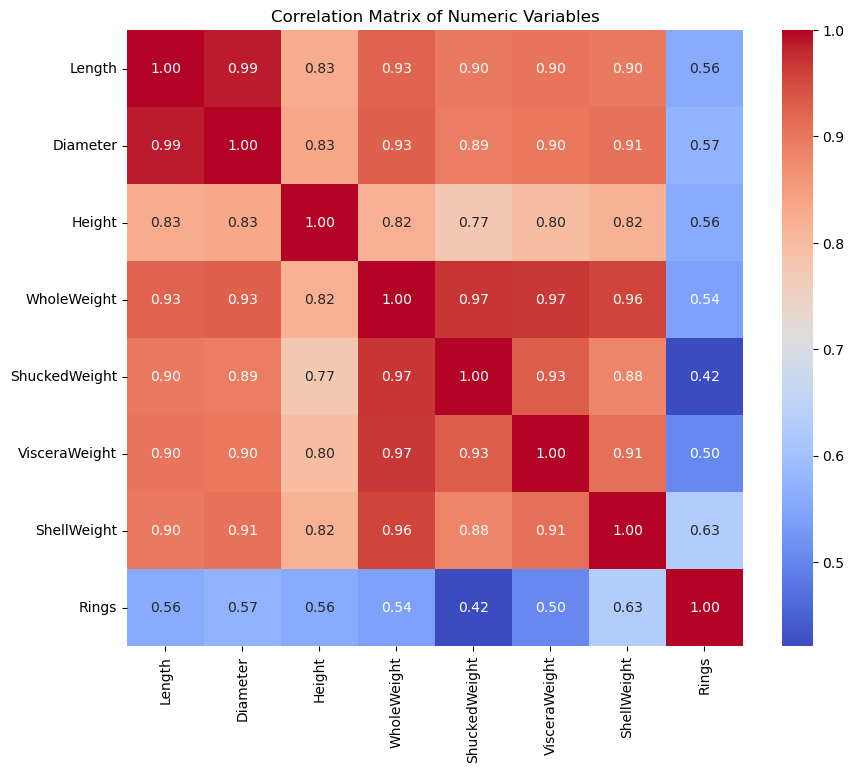

In [25]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path = r"C:\Users\PC\Downloads\abalone\abalone.data"
columns = ['Sex', 'Length', 'Diameter', 'Height', 
           'WholeWeight', 'ShuckedWeight', 'VisceraWeight', 
           'ShellWeight', 'Rings']
data = pd.read_csv(file_path, header=None, names=columns)

numeric_data = data.drop(columns=['Sex'])

sns.pairplot(numeric_data, diag_kind='kde', corner=True)
plt.suptitle("Scatter Plot Matrix of Numeric Variables", y=1.02)
plt.show()

correlation_matrix = numeric_data.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix of Numeric Variables")
plt.show()


In [26]:
from sklearn.model_selection import train_test_split

X = numeric_data.drop(columns=['Rings'])
y = numeric_data['Rings']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


Размер обучающей выборки: (3341, 7)
Размер тестовой выборки: (836, 7)


In [27]:
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import numpy as np

model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)

X_train_sm = sm.add_constant(X_train) 
ols_model = sm.OLS(y_train, X_train_sm).fit()
print(ols_model.summary())


Intercept: 2.9868051102562774
Coefficients: [ -1.52110421  13.48015869  11.39950956   9.15448479 -20.5802062
  -8.85247071   8.6416252 ]
                            OLS Regression Results                            
Dep. Variable:                  Rings   R-squared:                       0.526
Model:                            OLS   Adj. R-squared:                  0.525
Method:                 Least Squares   F-statistic:                     528.4
Date:                Thu, 09 Jan 2025   Prob (F-statistic):               0.00
Time:                        19:23:13   Log-Likelihood:                -7386.7
No. Observations:                3341   AIC:                         1.479e+04
Df Residuals:                    3333   BIC:                         1.484e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025    

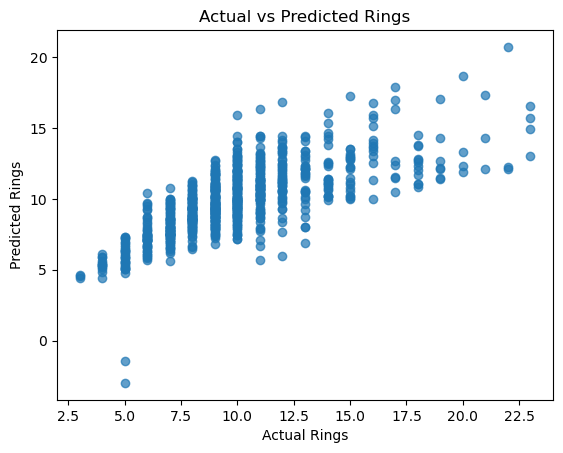

Bias: -0.004168266031557588
Variance: 5.819234595230384


In [28]:

y_pred = model.predict(X_test)


plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Rings")
plt.ylabel("Predicted Rings")
plt.title("Actual vs Predicted Rings")
plt.show()

bias = np.mean(y_test - y_pred)
variance = np.var(y_pred)

print("Bias:", bias)
print("Variance:", variance)


In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("Mean Absolute Error (MAE):", mae)
print("R-squared (R²):", r2)


Mean Squared Error (MSE): 5.055541144299385
Root Mean Squared Error (RMSE): 2.248453055836253
Mean Absolute Error (MAE): 1.629248267393658
R-squared (R²): 0.532984475772452
